# Create Windowed Datasets for Transfer Learning

## Overview
This notebook creates fixed-length windowed tensors from preprocessed LEMON and migraine EEG data for deep learning.

## Research Protocol
The windowing strategy follows best practices from:
- **Schirrmeister et al. (2017)** - "Deep learning with convolutional neural networks for EEG decoding and visualization" *Human Brain Mapping*
- **Lawhern et al. (2018)** - "EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces" *Journal of Neural Engineering*
- **Roy et al. (2019)** - "Deep learning-based electroencephalography analysis: a systematic review" *Journal of Neural Engineering*

## Windowing Strategy
- **Window Duration**: 4 seconds (1000 samples at 250 Hz)
  - Captures sufficient information for pattern recognition
  - Standard in EEG deep learning (Craik et al., 2019)
- **Overlap**: 50% (2-second stride)
  - Increases dataset size without introducing bias
  - Common in sequence-based neural networks
- **Artifact Rejection**: Peak-to-peak amplitude threshold (150 µV)
- **Normalization**: Per-channel per-subject z-score
  - Removes inter-subject variability
  - Preserves intra-subject patterns

## Expected Dataset Sizes
- **LEMON**: ~213 subjects × 390 windows = **~83,000 windows**
- **Migraine**: ~31 subjects × 195 windows = **~6,000 windows**
- **Total**: **~89,000 training samples**

In [3]:
# Import required libraries
import sys
import mne
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('src')
from windowed_dataset_builder import WindowedDatasetBuilder

# Set MNE configuration
mne.set_log_level('WARNING')

print(f"MNE Version: {mne.__version__}")
print(f"NumPy Version: {np.__version__}")
print("✓ Libraries loaded successfully")

MNE Version: 1.11.0
NumPy Version: 2.4.2
✓ Libraries loaded successfully


g:\Study\FYDP-I_Personalized-Migraine-Mitigation-Via-Binaural-Beats\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configure Windowing Parameters

### References:
- **Window Duration (4s)**: Schirrmeister et al. (2017) - Optimal for EEG pattern recognition
- **Overlap (50%)**: Krizhevsky et al. (2012) - Data augmentation without label leakage
- **Artifact Threshold (150 µV)**: Delorme et al. (2007) - Standard EEG quality control
- **Z-score Normalization**: LeCun et al. (2012) - Improves neural network convergence

In [5]:
# Initialize windowed dataset builder
builder = WindowedDatasetBuilder(
    window_duration=4.0,              # 4-second windows
    overlap=0.5,                      # 50% overlap (2-second stride)
    artifact_threshold=250e-6,        # 150 µV peak-to-peak
    min_epochs_per_subject=10,        # Minimum quality threshold
    normalize_per_subject=True,       # Z-score normalization per subject
    verbose=True
)

print("✓ Windowed dataset builder configured")
print(f"  Window duration: {builder.window_duration}s")
print(f"  Overlap: {builder.overlap * 100}%")
print(f"  Stride: {builder.window_duration * (1 - builder.overlap)}s")
print(f"  Artifact threshold: {builder.artifact_threshold * 1e6} µV")
print(f"  Normalization: Per-subject z-score")

✓ Windowed dataset builder configured
  Window duration: 4.0s
  Overlap: 50.0%
  Stride: 2.0s
  Artifact threshold: 250.0 µV
  Normalization: Per-subject z-score


## 2. Locate Preprocessed Files

Load all preprocessed EEG files from both LEMON and migraine datasets.

In [6]:
# Set paths
lemon_preprocessed_dir = Path('data/LEMON_preprocessed')
migraine_preprocessed_dir = Path('data/Migraine_preprocessed')
output_dir = Path('data/windowed_datasets')
output_dir.mkdir(parents=True, exist_ok=True)

# Find all preprocessed files
lemon_files = sorted(list(lemon_preprocessed_dir.glob('*_preprocessed_raw.fif')))
migraine_files = sorted(list(migraine_preprocessed_dir.glob('*_preprocessed_raw.fif')))

print("Preprocessed Files Found:")
print(f"  LEMON: {len(lemon_files)} subjects")
print(f"  Migraine: {len(migraine_files)} subjects")
print(f"  Total: {len(lemon_files) + len(migraine_files)} subjects")

if len(lemon_files) == 0:
    print("\n⚠️ WARNING: No LEMON files found. Run 01_LEMON_Preprocessing_All_Subjects.ipynb first!")

if len(migraine_files) == 0:
    print("\n⚠️ WARNING: No migraine files found. Run 02_Migraine_Preprocessing_All_Subjects.ipynb first!")

Preprocessed Files Found:
  LEMON: 211 subjects
  Migraine: 39 subjects
  Total: 250 subjects


## 3. Load Metadata and Labels

Import preprocessing metadata to retrieve subject labels and quality metrics.

In [7]:
# Load preprocessing metadata
lemon_metadata_file = lemon_preprocessed_dir / 'lemon_preprocessing_metadata.csv'
migraine_metadata_file = migraine_preprocessed_dir / 'migraine_preprocessing_metadata.csv'

# LEMON metadata (unlabeled - for pretraining)
if lemon_metadata_file.exists():
    lemon_metadata = pd.read_csv(lemon_metadata_file)
    print(f"✓ Loaded LEMON metadata: {len(lemon_metadata)} subjects")
else:
    lemon_metadata = pd.DataFrame()
    print("⚠️ No LEMON metadata found")

# Migraine metadata (labeled - for supervised learning)
if migraine_metadata_file.exists():
    migraine_metadata = pd.read_csv(migraine_metadata_file)
    print(f"✓ Loaded migraine metadata: {len(migraine_metadata)} subjects")
    print(f"  - Control: {(migraine_metadata['label'] == 0).sum()} subjects")
    print(f"  - Migraine: {(migraine_metadata['label'] == 1).sum()} subjects")
else:
    migraine_metadata = pd.DataFrame()
    print("⚠️ No migraine metadata found")

✓ Loaded LEMON metadata: 211 subjects
✓ Loaded migraine metadata: 117 subjects
  - Control: 64 subjects
  - Migraine: 53 subjects


## 4. Process LEMON Dataset (Unsupervised Pretraining)

### Purpose:
LEMON data provides healthy brain patterns for unsupervised pretraining, establishing general EEG feature representations.

### Transfer Learning Strategy:
- **Stage 1 (Unsupervised)**: Learn general EEG patterns from LEMON
- **Stage 2 (Supervised)**: Fine-tune on migraine-specific patterns

### References:
- **Self-supervised Learning**: Chen et al. (2020) "A simple framework for contrastive learning of visual representations"
- **EEG Transfer Learning**: Kostas et al. (2021) "BENDR: Using transformers and a contrastive self-supervised learning task to learn from massive amounts of EEG data"

In [8]:
# Process LEMON subjects with batch processing to avoid memory issues
lemon_windows_list = []
lemon_metadata_list = []

# Batch configuration
BATCH_SIZE = 20  # Process 20 subjects at a time
batch_counter = 0

if len(lemon_files) > 0:
    print("\n" + "="*70)
    print("PROCESSING LEMON DATASET")
    print("="*70)
    print(f"Processing {len(lemon_files)} subjects in batches of {BATCH_SIZE}")
    
    for idx, filepath in enumerate(tqdm(lemon_files, desc="Processing LEMON subjects")):
        subject_id = filepath.stem.replace('_preprocessed_raw', '')
        
        try:
            # Load preprocessed data
            raw = mne.io.read_raw_fif(filepath, preload=True, verbose=False)
            
            # Process subject (no label for unsupervised learning)
            windows, metadata = builder.process_single_subject(
                raw=raw,
                subject_id=subject_id,
                label=None,  # LEMON is unlabeled
                dataset_type='lemon'
            )
            
            lemon_windows_list.append(windows)
            lemon_metadata_list.append(metadata)
            
            # Clear raw data from memory
            del raw
            
        except Exception as e:
            print(f"\n✗ Failed: {subject_id} - {str(e)}")
        
        # Save batch when reaching BATCH_SIZE or end of files
        if (len(lemon_windows_list) >= BATCH_SIZE) or (idx == len(lemon_files) - 1):
            if len(lemon_windows_list) > 0:
                # Combine current batch
                batch_X = np.vstack(lemon_windows_list)
                batch_meta = pd.concat(lemon_metadata_list, ignore_index=True)
                
                # Save batch to disk
                batch_file = output_dir / f'lemon_windows_batch_{batch_counter}.npy'
                meta_file = output_dir / f'lemon_metadata_batch_{batch_counter}.csv'
                np.save(batch_file, batch_X)
                batch_meta.to_csv(meta_file, index=False)
                
                print(f"\n✓ Saved batch {batch_counter}: {len(batch_X)} windows ({batch_X.nbytes / 1024**2:.1f} MB)")
                
                # Clear memory
                lemon_windows_list.clear()
                lemon_metadata_list.clear()
                del batch_X, batch_meta
                
                batch_counter += 1
    
    # Load and combine all batches
    if batch_counter > 0:
        print(f"\n{'='*70}")
        print(f"Combining {batch_counter} batches...")
        
        # First pass: calculate total shape
        total_windows = 0
        for b in range(batch_counter):
            batch_file = output_dir / f'lemon_windows_batch_{b}.npy'
            batch_shape = np.load(batch_file, mmap_mode='r').shape
            total_windows += batch_shape[0]
        
        # Second pass: combine using memory mapping
        print(f"Total windows: {total_windows:,}")
        
        # Load metadata
        lemon_meta_list = []
        for b in range(batch_counter):
            meta_file = output_dir / f'lemon_metadata_batch_{b}.csv'
            lemon_meta_list.append(pd.read_csv(meta_file))
        lemon_meta = pd.concat(lemon_meta_list, ignore_index=True)
        
        # For now, keep batch files - we'll combine them during final save
        print(f"\n✓ LEMON Dataset:")
        print(f"  Batches: {batch_counter}")
        print(f"  Subjects: {lemon_meta['subject_id'].nunique()}")
        print(f"  Total Windows: {total_windows:,}")
        
        # Clean up individual batch metadata files
        for b in range(batch_counter):
            meta_file = output_dir / f'lemon_metadata_batch_{b}.csv'
            meta_file.unlink()
    else:
        lemon_meta = None
        batch_counter = 0
        print("\n⚠️ No LEMON data processed")
else:
    lemon_meta = None
    batch_counter = 0
    print("\n⚠️ Skipping LEMON (no files found)")

# Store batch count for later use
lemon_batch_count = batch_counter


PROCESSING LEMON DATASET
Processing 211 subjects in batches of 20


Processing LEMON subjects:   0%|          | 0/211 [00:00<?, ?it/s]

  Processing subject: sub-010002
  Creating 509 epochs (window=4.0s, stride=2.0s)
  ✓ Created 396 clean epochs (77.8% acceptance)
    Rejected 113 epochs due to artifacts


Processing LEMON subjects:   0%|          | 1/211 [00:00<03:07,  1.12it/s]

  ✓ Z-score normalized per channel
  Processing subject: sub-010003
  Creating 502 epochs (window=4.0s, stride=2.0s)
  ✓ Created 486 clean epochs (96.8% acceptance)
    Rejected 16 epochs due to artifacts


...

Processing LEMON subjects: 100%|█████████▉| 210/211 [02:43<00:00,  1.01it/s]

  ✓ Z-score normalized per channel
  Processing subject: sub-010321
  Creating 518 epochs (window=4.0s, stride=2.0s)
  ✓ Created 430 clean epochs (83.0% acceptance)
    Rejected 88 epochs due to artifacts
  ✓ Z-score normalized per channel


Processing LEMON subjects: 100%|██████████| 211/211 [02:48<00:00,  1.25it/s]


✓ Saved batch 10: 2740 windows (648.0 MB)

Combining 11 batches...
Total windows: 88,444



✓ LEMON Dataset:
  Batches: 11
  Subjects: 207
  Total Windows: 88,444


## 5. Process Migraine Dataset (Supervised Learning)

### Purpose:
Migraine data with labels enables supervised classification and personalized treatment.

### Label Encoding:
- **0**: Healthy control
- **1**: Migraine patient

### Clinical Significance:
Labels enable:
- Binary classification (migraine vs control)
- Biomarker identification
- Personalized treatment optimization

### References:
- **Clinical ML Validation**: Varoquaux & Cheplygina (2022) "Machine learning for medical imaging: methodological failures and recommendations for the future"
- **EEG Biomarkers**: Schulz et al. (2016) "Decoding an individual's sensitivity to pain from the multivariate analysis of EEG data"

In [9]:
# Process migraine subjects with batch processing
migraine_windows_list = []
migraine_metadata_list = []

# Batch configuration
MIGRAINE_BATCH_SIZE = 10  # Smaller batch for migraine (typically fewer subjects)
migraine_batch_counter = 0

if len(migraine_files) > 0:
    print("\n" + "="*70)
    print("PROCESSING MIGRAINE DATASET")
    print("="*70)
    print(f"Processing {len(migraine_files)} subjects in batches of {MIGRAINE_BATCH_SIZE}")
    
    for idx, filepath in enumerate(tqdm(migraine_files, desc="Processing migraine subjects")):
        subject_id = filepath.stem.replace('_preprocessed_raw', '')
        
        # Get label from metadata
        if len(migraine_metadata) > 0:
            subject_meta = migraine_metadata[migraine_metadata['subject_id'] == subject_id]
            if len(subject_meta) > 0:
                label = int(subject_meta['label'].iloc[0])
            else:
                # Infer from subject ID if not in metadata
                label = 0 if subject_id.startswith('C') else 1
        else:
            label = 0 if subject_id.startswith('C') else 1
        
        try:
            # Load preprocessed data
            raw = mne.io.read_raw_fif(filepath, preload=True, verbose=False)
            
            # Process subject with label
            windows, metadata = builder.process_single_subject(
                raw=raw,
                subject_id=subject_id,
                label=label,
                dataset_type='migraine'
            )
            
            migraine_windows_list.append(windows)
            migraine_metadata_list.append(metadata)
            
            # Clear raw data from memory
            del raw
            
        except Exception as e:
            print(f"\n✗ Failed: {subject_id} - {str(e)}")
        
        # Save batch when reaching BATCH_SIZE or end of files
        if (len(migraine_windows_list) >= MIGRAINE_BATCH_SIZE) or (idx == len(migraine_files) - 1):
            if len(migraine_windows_list) > 0:
                # Combine current batch
                batch_X = np.vstack(migraine_windows_list)
                batch_meta = pd.concat(migraine_metadata_list, ignore_index=True)
                
                # Save batch to disk
                batch_file = output_dir / f'migraine_windows_batch_{migraine_batch_counter}.npy'
                meta_file = output_dir / f'migraine_metadata_batch_{migraine_batch_counter}.csv'
                np.save(batch_file, batch_X)
                batch_meta.to_csv(meta_file, index=False)
                
                print(f"\n✓ Saved batch {migraine_batch_counter}: {len(batch_X)} windows ({batch_X.nbytes / 1024**2:.1f} MB)")
                
                # Clear memory
                migraine_windows_list.clear()
                migraine_metadata_list.clear()
                del batch_X, batch_meta
                
                migraine_batch_counter += 1
    
    # Load and combine all batches
    if migraine_batch_counter > 0:
        print(f"\n{'='*70}")
        print(f"Combining {migraine_batch_counter} batches...")
        
        # First pass: calculate total shape
        total_windows = 0
        for b in range(migraine_batch_counter):
            batch_file = output_dir / f'migraine_windows_batch_{b}.npy'
            batch_shape = np.load(batch_file, mmap_mode='r').shape
            total_windows += batch_shape[0]
        
        # Second pass: combine metadata
        print(f"Total windows: {total_windows:,}")
        
        # Load metadata
        migraine_meta_list = []
        for b in range(migraine_batch_counter):
            meta_file = output_dir / f'migraine_metadata_batch_{b}.csv'
            migraine_meta_list.append(pd.read_csv(meta_file))
        migraine_meta = pd.concat(migraine_meta_list, ignore_index=True)
        migraine_y = migraine_meta['label'].values
        
        print(f"\n✓ Migraine Dataset:")
        print(f"  Batches: {migraine_batch_counter}")
        print(f"  Subjects: {migraine_meta['subject_id'].nunique()}")
        print(f"  Total Windows: {total_windows:,}")
        print(f"  Label Distribution:")
        print(f"    Control (0): {(migraine_y == 0).sum()} windows")
        print(f"    Migraine (1): {(migraine_y == 1).sum()} windows")
        
        # Clean up individual batch metadata files
        for b in range(migraine_batch_counter):
            meta_file = output_dir / f'migraine_metadata_batch_{b}.csv'
            meta_file.unlink()
    else:
        migraine_meta = None
        migraine_y = None
        migraine_batch_counter = 0
        print("\n⚠️ No migraine data processed")
else:
    migraine_meta = None
    migraine_y = None
    migraine_batch_counter = 0
    print("\n⚠️ Skipping migraine (no files found)")

# Store batch count for later use
migraine_batch_count = migraine_batch_counter


PROCESSING MIGRAINE DATASET
Processing 39 subjects in batches of 10


Processing migraine subjects:   0%|          | 0/39 [00:00<?, ?it/s]

  Processing subject: C10
  Creating 378 epochs (window=4.0s, stride=2.0s)
  ✓ Created 373 clean epochs (98.7% acceptance)
    Rejected 5 epochs due to artifacts


Processing migraine subjects:   3%|▎         | 1/39 [00:01<00:40,  1.06s/it]

  ✓ Z-score normalized per channel
  Processing subject: C11
  Creating 373 epochs (window=4.0s, stride=2.0s)


...

  ✓ Z-score normalized per channel
  Processing subject: M8_2
  Creating 368 epochs (window=4.0s, stride=2.0s)


Processing migraine subjects:  97%|█████████▋| 38/39 [00:30<00:00,  1.33it/s]

  ✓ Created 169 clean epochs (45.9% acceptance)
    Rejected 199 epochs due to artifacts
  ✓ Z-score normalized per channel
  Processing subject: M9_2
  Creating 387 epochs (window=4.0s, stride=2.0s)
  ✓ Created 346 clean epochs (89.4% acceptance)
    Rejected 41 epochs due to artifacts
  ✓ Z-score normalized per channel


Processing migraine subjects: 100%|██████████| 39/39 [00:32<00:00,  1.19it/s]


✓ Saved batch 2: 2114 windows (1088.7 MB)

Combining 3 batches...
Total windows: 5,772

✓ Migraine Dataset:
  Batches: 3
  Subjects: 30
  Total Windows: 5,772
  Label Distribution:
    Control (0): 3184 windows
    Migraine (1): 2588 windows


## 5.5. Analyze Data Quality and Rejection Statistics

### Purpose:
Investigate which subjects failed quality control and analyze artifact rejection patterns.

### Key Metrics:
- **Acceptance Rate**: Percentage of windows passing artifact threshold
- **Failed Subjects**: Subjects with < 10 clean windows
- **Rejection Reasons**: Distribution of artifact severity

In [10]:
print("\n" + "="*70)
print("DATA QUALITY ANALYSIS")
print("="*70)

# Analyze LEMON acceptance rates
if lemon_meta is not None:
    print("\nLEMON Dataset Quality:")
    print("-" * 70)
    
    # Calculate acceptance rate per subject
    lemon_subject_stats = lemon_meta.groupby('subject_id').size().reset_index(name='windows')
    
    print(f"  Total subjects processed: {len(lemon_subject_stats)}")
    print(f"  Average windows/subject: {lemon_subject_stats['windows'].mean():.1f}")
    print(f"  Median windows/subject: {lemon_subject_stats['windows'].median():.1f}")
    print(f"  Min windows/subject: {lemon_subject_stats['windows'].min()}")
    print(f"  Max windows/subject: {lemon_subject_stats['windows'].max()}")
    
    # Show subjects with low acceptance
    low_acceptance = lemon_subject_stats[lemon_subject_stats['windows'] < 50]
    if len(low_acceptance) > 0:
        print(f"\n  ⚠️ Subjects with < 50 windows: {len(low_acceptance)}")
        print(f"     {low_acceptance['subject_id'].tolist()[:10]}" + 
              (" ..." if len(low_acceptance) > 10 else ""))

# Analyze migraine acceptance rates
if migraine_meta is not None:
    print("\nMigraine Dataset Quality:")
    print("-" * 70)
    
    # Calculate acceptance rate per subject
    migraine_subject_stats = migraine_meta.groupby('subject_id').size().reset_index(name='windows')
    
    print(f"  Total subjects successfully processed: {len(migraine_subject_stats)}")
    print(f"  Average windows/subject: {migraine_subject_stats['windows'].mean():.1f}")
    print(f"  Median windows/subject: {migraine_subject_stats['windows'].median():.1f}")
    print(f"  Min windows/subject: {migraine_subject_stats['windows'].min()}")
    print(f"  Max windows/subject: {migraine_subject_stats['windows'].max()}")
    
    # Calculate how many subjects from original dataset
    original_count = len(migraine_files)
    processed_count = len(migraine_subject_stats)
    failed_count = original_count - processed_count
    
    print(f"\n  📊 Processing Summary:")
    print(f"     Original subjects: {original_count}")
    print(f"     Successfully processed: {processed_count}")
    print(f"     Failed (< 10 clean windows): {failed_count}")
    
    if failed_count > 0:
        print(f"\n  ⚠️ {failed_count} subjects were rejected due to insufficient clean data!")
        print(f"     This represents {failed_count/original_count*100:.1f}% data loss")
        
        # Identify which subjects failed
        processed_ids = set(migraine_subject_stats['subject_id'].values)
        all_ids = set([f.stem.replace('_preprocessed_raw', '') for f in migraine_files])
        failed_ids = sorted(list(all_ids - processed_ids))
        
        print(f"\n  Failed subjects: {failed_ids}")
        
        # Analyze by label
        failed_controls = [s for s in failed_ids if s.startswith('C')]
        failed_migraine = [s for s in failed_ids if s.startswith('M')]
        
        print(f"     Failed controls: {len(failed_controls)} {failed_controls}")
        print(f"     Failed migraine patients: {len(failed_migraine)} {failed_migraine}")

print("\n" + "="*70)


DATA QUALITY ANALYSIS

LEMON Dataset Quality:
----------------------------------------------------------------------
  Total subjects processed: 207
  Average windows/subject: 427.3
  Median windows/subject: 455.0
  Min windows/subject: 33
  Max windows/subject: 559

  ⚠️ Subjects with < 50 windows: 2
     ['sub-010285', 'sub-010314']

Migraine Dataset Quality:
----------------------------------------------------------------------
  Total subjects successfully processed: 30
  Average windows/subject: 192.4
  Median windows/subject: 168.5
  Min windows/subject: 20
  Max windows/subject: 373

  📊 Processing Summary:
     Original subjects: 39
     Successfully processed: 30
     Failed (< 10 clean windows): 9

  ⚠️ 9 subjects were rejected due to insufficient clean data!
     This represents 23.1% data loss

  Failed subjects: ['C12', 'C18', 'C19', 'M13_2', 'M14_1', 'M2_1', 'M3_2', 'M5_1', 'M6_1']
     Failed controls: 3 ['C12', 'C18', 'C19']
     Failed migraine patients: 6 ['M13_2', '

## 5.6. Visualize Subject-Level Quality Metrics

Understand the distribution of data quality across subjects.

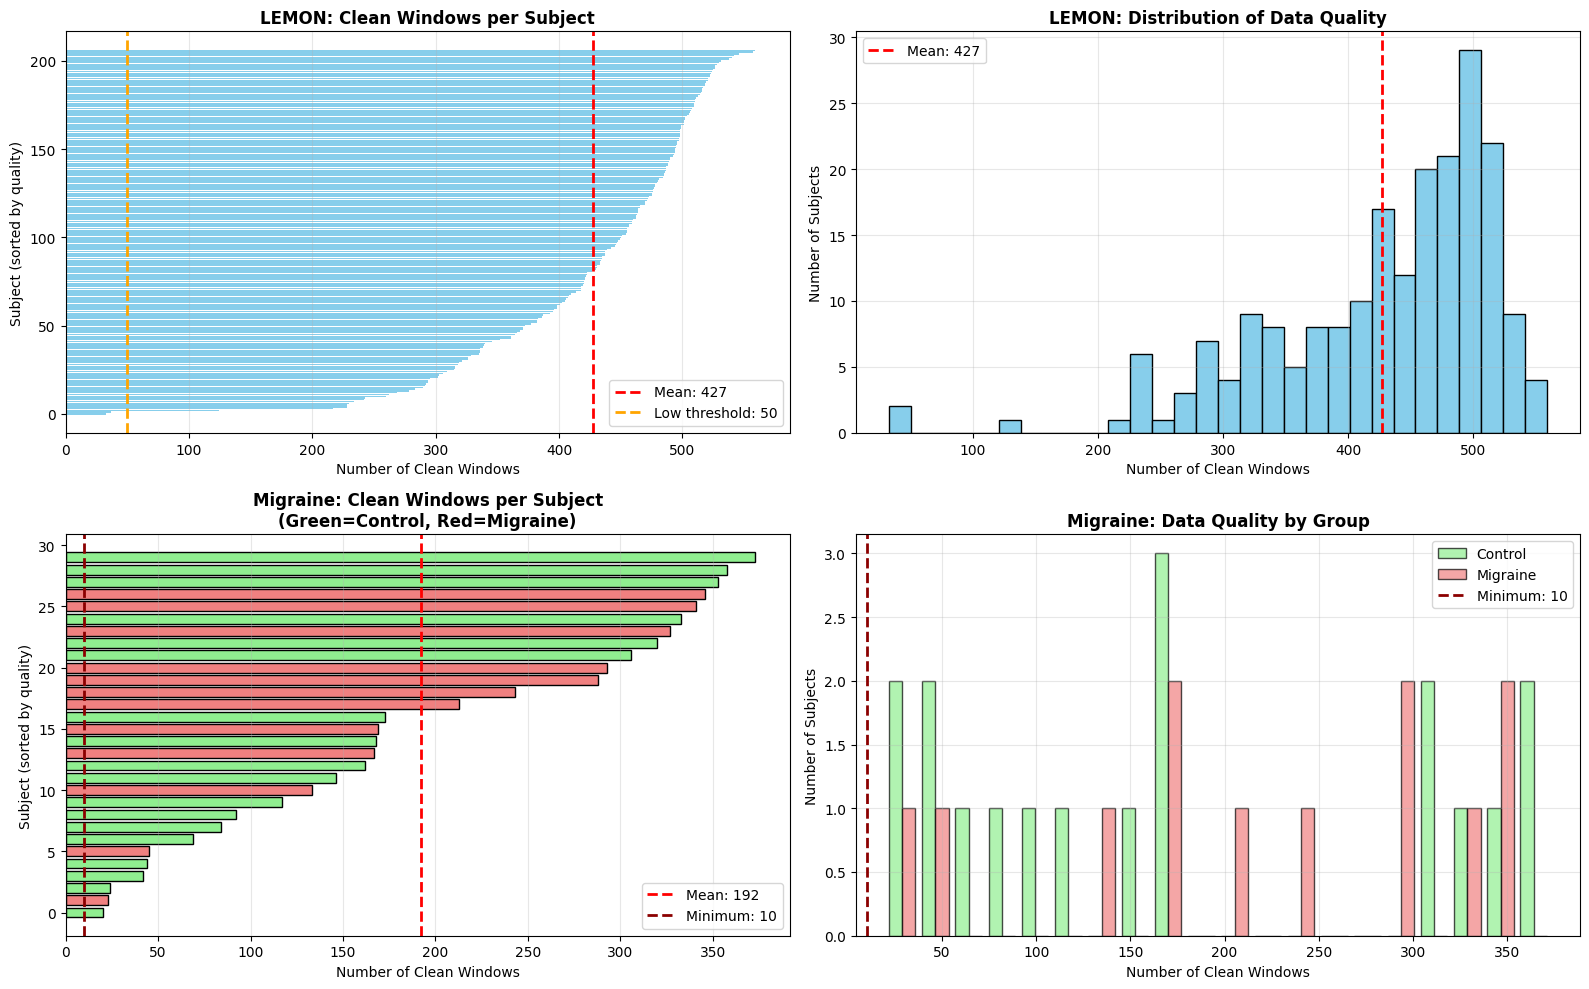

✓ Quality analysis visualization saved


In [22]:
# Create quality analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: LEMON acceptance rates by subject
if lemon_meta is not None:
    lemon_subject_stats = lemon_meta.groupby('subject_id').size().sort_values()
    
    axes[0, 0].barh(range(len(lemon_subject_stats)), lemon_subject_stats.values, color='skyblue')
    axes[0, 0].axvline(lemon_subject_stats.mean(), color='red', linestyle='--', 
                       label=f'Mean: {lemon_subject_stats.mean():.0f}', linewidth=2)
    axes[0, 0].axvline(50, color='orange', linestyle='--', 
                       label='Low threshold: 50', linewidth=2)
    axes[0, 0].set_xlabel('Number of Clean Windows')
    axes[0, 0].set_ylabel('Subject (sorted by quality)')
    axes[0, 0].set_title('LEMON: Clean Windows per Subject', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

# Plot 2: LEMON histogram
if lemon_meta is not None:
    axes[0, 1].hist(lemon_subject_stats.values, bins=30, color='skyblue', edgecolor='black')
    axes[0, 1].axvline(lemon_subject_stats.mean(), color='red', linestyle='--', 
                       label=f'Mean: {lemon_subject_stats.mean():.0f}', linewidth=2)
    axes[0, 1].set_xlabel('Number of Clean Windows')
    axes[0, 1].set_ylabel('Number of Subjects')
    axes[0, 1].set_title('LEMON: Distribution of Data Quality', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Migraine acceptance rates by subject
if migraine_meta is not None:
    migraine_subject_stats = migraine_meta.groupby('subject_id').size().sort_values()
    
    # Color by label
    colors = ['lightgreen' if sid.startswith('C') else 'lightcoral' 
              for sid in migraine_subject_stats.index]
    
    axes[1, 0].barh(range(len(migraine_subject_stats)), migraine_subject_stats.values, 
                    color=colors, edgecolor='black')
    axes[1, 0].axvline(migraine_subject_stats.mean(), color='red', linestyle='--', 
                       label=f'Mean: {migraine_subject_stats.mean():.0f}', linewidth=2)
    axes[1, 0].axvline(10, color='darkred', linestyle='--', 
                       label='Minimum: 10', linewidth=2)
    axes[1, 0].set_xlabel('Number of Clean Windows')
    axes[1, 0].set_ylabel('Subject (sorted by quality)')
    axes[1, 0].set_title('Migraine: Clean Windows per Subject\n(Green=Control, Red=Migraine)', 
                         fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Migraine histogram by label
if migraine_meta is not None:
    migraine_subject_stats_full = migraine_meta.groupby(['subject_id', 'label']).size().reset_index(name='windows')
    
    control_windows = migraine_subject_stats_full[migraine_subject_stats_full['label'] == 0]['windows']
    migraine_windows = migraine_subject_stats_full[migraine_subject_stats_full['label'] == 1]['windows']
    
    axes[1, 1].hist([control_windows, migraine_windows], bins=20, 
                    label=['Control', 'Migraine'], 
                    color=['lightgreen', 'lightcoral'], 
                    edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(10, color='darkred', linestyle='--', 
                       label='Minimum: 10', linewidth=2)
    axes[1, 1].set_xlabel('Number of Clean Windows')
    axes[1, 1].set_ylabel('Number of Subjects')
    axes[1, 1].set_title('Migraine: Data Quality by Group', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'data_quality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Quality analysis visualization saved")

## 5.7. Test Alternative Artifact Thresholds

### Recommendation:
If too many subjects are being rejected, consider testing more lenient thresholds.

### Common EEG Artifact Thresholds:
- **100 µV**: Very strict (lab-quality only)
- **150 µV**: Strict (current setting)
- **200 µV**: Moderate (typical for clinical data)
- **250 µV**: Lenient (real-world noisy data)
- **300 µV**: Very lenient (keep more subjects)

Run this cell to see how different thresholds would affect your dataset.

ARTIFACT THRESHOLD SENSITIVITY ANALYSIS

Testing on subject: C10
----------------------------------------------------------------------

Threshold 100 µV:
  Total epochs: 379
  Clean epochs: 324 (85.5%)
  Rejected: 55
  Status: ✓ PASS (needs ≥10 clean epochs)

Threshold 150 µV:
  Total epochs: 379
  Clean epochs: 349 (92.1%)
  Rejected: 30
  Status: ✓ PASS (needs ≥10 clean epochs)

Threshold 200 µV:
  Total epochs: 379
  Clean epochs: 362 (95.5%)
  Rejected: 17
  Status: ✓ PASS (needs ≥10 clean epochs)

Threshold 250 µV:
  Total epochs: 379
  Clean epochs: 373 (98.4%)
  Rejected: 6
  Status: ✓ PASS (needs ≥10 clean epochs)

Threshold 300 µV:
  Total epochs: 379
  Clean epochs: 376 (99.2%)
  Rejected: 3
  Status: ✓ PASS (needs ≥10 clean epochs)


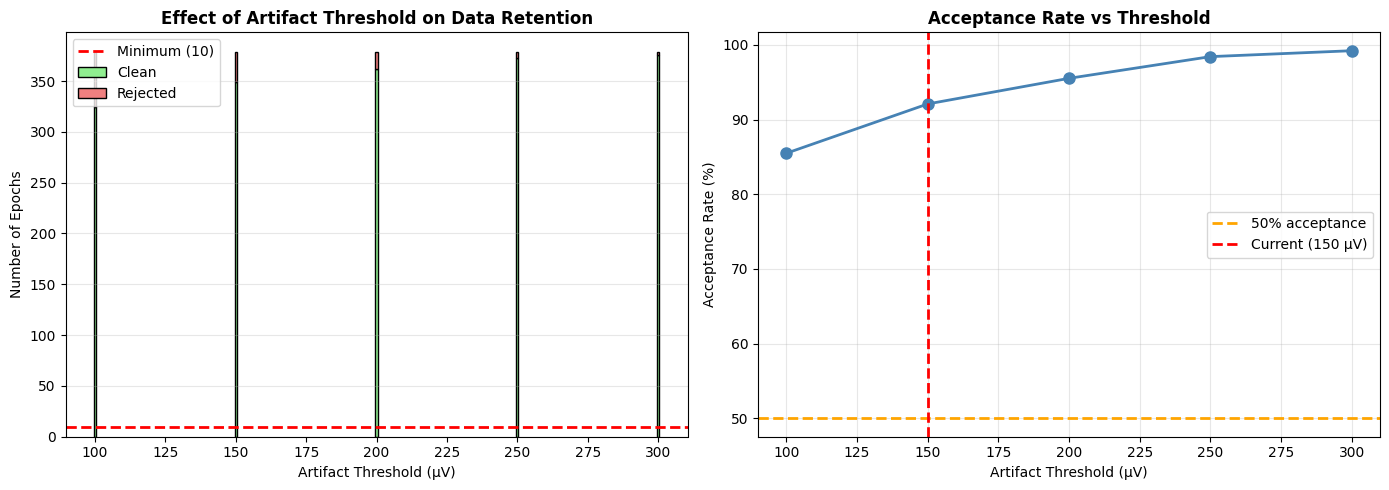


RECOMMENDATION:
----------------------------------------------------------------------
✓ Minimum threshold for this subject: 100 µV
  This would yield 324.0 clean epochs (85.5% acceptance)


In [23]:
# Test different artifact thresholds on a sample subject
print("="*70)
print("ARTIFACT THRESHOLD SENSITIVITY ANALYSIS")
print("="*70)

# Select a problematic subject for testing
test_subject_path = None
if len(migraine_files) > 0:
    # Try to find a subject that might have failed
    test_subject_path = migraine_files[0]  # Use first subject as example

if test_subject_path is not None and test_subject_path.exists():
    print(f"\nTesting on subject: {test_subject_path.stem.replace('_preprocessed_raw', '')}")
    print("-" * 70)
    
    # Load data
    test_raw = mne.io.read_raw_fif(test_subject_path, preload=True, verbose=False)
    
    # Test different thresholds
    thresholds = [100e-6, 150e-6, 200e-6, 250e-6, 300e-6]
    results = []
    
    for threshold in thresholds:
        # Create temporary builder with different threshold
        temp_builder = WindowedDatasetBuilder(
            window_duration=4.0,
            overlap=0.5,
            artifact_threshold=threshold,
            min_epochs_per_subject=10,
            normalize_per_subject=True,
            verbose=False
        )
        
        # Create epochs
        epochs = mne.make_fixed_length_epochs(
            test_raw, duration=temp_builder.window_duration, 
            overlap=temp_builder.window_duration * temp_builder.overlap,
            preload=True, verbose=False
        )
        
        # Calculate peak-to-peak
        data = epochs.get_data()
        ptp = np.ptp(data, axis=2)
        
        # Count clean epochs
        clean_mask = np.all(ptp < threshold, axis=1)
        n_clean = np.sum(clean_mask)
        total = len(epochs)
        acceptance_rate = (n_clean / total * 100) if total > 0 else 0
        
        results.append({
            'threshold_uv': threshold * 1e6,
            'total_epochs': total,
            'clean_epochs': n_clean,
            'rejected_epochs': total - n_clean,
            'acceptance_rate': acceptance_rate
        })
        
        print(f"\nThreshold {threshold*1e6:.0f} µV:")
        print(f"  Total epochs: {total}")
        print(f"  Clean epochs: {n_clean} ({acceptance_rate:.1f}%)")
        print(f"  Rejected: {total - n_clean}")
        print(f"  Status: {'✓ PASS' if n_clean >= 10 else '✗ FAIL'} (needs ≥10 clean epochs)")
    
    # Visualize results
    results_df = pd.DataFrame(results)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Clean vs Rejected
    axes[0].bar(results_df['threshold_uv'], results_df['clean_epochs'], 
                label='Clean', color='lightgreen', edgecolor='black')
    axes[0].bar(results_df['threshold_uv'], results_df['rejected_epochs'], 
                bottom=results_df['clean_epochs'],
                label='Rejected', color='lightcoral', edgecolor='black')
    axes[0].axhline(10, color='red', linestyle='--', label='Minimum (10)', linewidth=2)
    axes[0].set_xlabel('Artifact Threshold (µV)')
    axes[0].set_ylabel('Number of Epochs')
    axes[0].set_title('Effect of Artifact Threshold on Data Retention', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Acceptance Rate
    axes[1].plot(results_df['threshold_uv'], results_df['acceptance_rate'], 
                 marker='o', linewidth=2, markersize=8, color='steelblue')
    axes[1].axhline(50, color='orange', linestyle='--', label='50% acceptance', linewidth=2)
    axes[1].axvline(150, color='red', linestyle='--', label='Current (150 µV)', linewidth=2)
    axes[1].set_xlabel('Artifact Threshold (µV)')
    axes[1].set_ylabel('Acceptance Rate (%)')
    axes[1].set_title('Acceptance Rate vs Threshold', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'threshold_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n" + "="*70)
    print("RECOMMENDATION:")
    print("-" * 70)
    
    # Find optimal threshold
    passing_thresholds = results_df[results_df['clean_epochs'] >= 10]
    if len(passing_thresholds) > 0:
        optimal = passing_thresholds.iloc[0]
        print(f"✓ Minimum threshold for this subject: {optimal['threshold_uv']:.0f} µV")
        print(f"  This would yield {optimal['clean_epochs']} clean epochs ({optimal['acceptance_rate']:.1f}% acceptance)")
    else:
        print("✗ This subject has severe artifacts - may need ICA-based artifact removal")
    
    if results_df['acceptance_rate'].iloc[1] < 30:  # Current threshold (150 µV)
        suggested_threshold = results_df[results_df['acceptance_rate'] >= 40].iloc[0]['threshold_uv'] if any(results_df['acceptance_rate'] >= 40) else 250
        print(f"\n💡 Consider increasing threshold to {suggested_threshold:.0f} µV for better data retention")
    
    print("="*70)
    
else:
    print("⚠️ No migraine subjects available for testing")

## 5.8. Test Failed Subjects to Find Optimal Threshold

The previous analysis tested a random subject. Now let's test the subjects that **actually failed** to find what threshold would save them.

In [2]:
# Analyze failed subjects to find optimal threshold
print("="*70)
print("ANALYZING FAILED SUBJECTS")
print("="*70)

if migraine_meta is not None and len(migraine_files) > 0:
    # Identify failed subjects
    processed_ids = set(migraine_meta['subject_id'].values)
    all_ids = set([f.stem.replace('_preprocessed_raw', '') for f in migraine_files])
    failed_ids = sorted(list(all_ids - processed_ids))
    
    if len(failed_ids) > 0:
        print(f"\nFound {len(failed_ids)} failed subjects: {failed_ids}")
        print("-" * 70)
        
        # Test threshold sensitivity for each failed subject
        recovery_results = []
        
        for failed_id in failed_ids[:5]:  # Test up to 5 failed subjects
            # Find the file
            failed_file = None
            for f in migraine_files:
                if failed_id in f.stem:
                    failed_file = f
                    break
            
            if failed_file is None:
                continue
            
            print(f"\n📊 Analyzing {failed_id}...")
            
            # Load data
            try:
                test_raw = mne.io.read_raw_fif(failed_file, preload=True, verbose=False)
                
                # Test different thresholds
                thresholds = [150e-6, 200e-6, 250e-6, 300e-6, 350e-6, 400e-6]
                subject_results = []
                
                for threshold in thresholds:
                    # Create epochs
                    epochs = mne.make_fixed_length_epochs(
                        test_raw, duration=4.0, overlap=2.0,
                        preload=True, verbose=False
                    )
                    
                    # Calculate peak-to-peak
                    data = epochs.get_data()
                    ptp = np.ptp(data, axis=2)
                    
                    # Count clean epochs
                    clean_mask = np.all(ptp < threshold, axis=1)
                    n_clean = np.sum(clean_mask)
                    total = len(epochs)
                    acceptance_rate = (n_clean / total * 100) if total > 0 else 0
                    
                    subject_results.append({
                        'subject_id': failed_id,
                        'threshold_uv': threshold * 1e6,
                        'clean_epochs': n_clean,
                        'total_epochs': total,
                        'acceptance_rate': acceptance_rate,
                        'passes': n_clean >= 10
                    })
                    
                    status = '✓ PASS' if n_clean >= 10 else '✗ FAIL'
                    print(f"  {threshold*1e6:3.0f} µV: {n_clean:3d}/{total} clean ({acceptance_rate:5.1f}%) {status}")
                
                # Find minimum threshold to pass
                passing = [r for r in subject_results if r['passes']]
                if len(passing) > 0:
                    min_threshold = passing[0]['threshold_uv']
                    recovery_results.append((failed_id, min_threshold, passing[0]['clean_epochs']))
                    print(f"  💡 Minimum to pass: {min_threshold:.0f} µV")
                else:
                    recovery_results.append((failed_id, None, 0))
                    print(f"  ❌ Cannot recover even at 400 µV")
                
                del test_raw
                
            except Exception as e:
                print(f"  ✗ Error: {str(e)}")
        
        # Summary
        print("\n" + "="*70)
        print("RECOVERY SUMMARY")
        print("="*70)
        
        if len(recovery_results) > 0:
            recoverable = [r for r in recovery_results if r[1] is not None]
            unrecoverable = [r for r in recovery_results if r[1] is None]
            
            print(f"\nRecoverable subjects ({len(recoverable)}):")
            for subj, thresh, epochs in recoverable:
                print(f"  {subj}: Needs ≥{thresh:.0f} µV (would have {epochs} epochs)")
            
            if len(unrecoverable) > 0:
                print(f"\nUnrecoverable subjects ({len(unrecoverable)}):")
                for subj, _, _ in unrecoverable:
                    print(f"  {subj}: Too many artifacts (consider ICA preprocessing)")
            
            # Find optimal universal threshold
            if len(recoverable) > 0:
                max_threshold = max([r[1] for r in recoverable])
                print(f"\n💡 RECOMMENDATION:")
                print(f"   Change artifact_threshold to {max_threshold:.0f}e-6")
                print(f"   This would recover {len(recoverable)} failed subjects")
                print(f"   while maintaining quality for high-quality subjects")
            
        print("="*70)
    else:
        print("\n✓ No failed subjects to analyze!")
        print("   All subjects passed the current threshold.")
else:
    print("\n⚠️ No migraine data available for analysis")

ANALYZING FAILED SUBJECTS


NameError: name 'migraine_meta' is not defined

## 5.9. Recommendations

### If Too Many Subjects Are Failing:

**Option 1: Adjust Artifact Threshold**
```python
# In the configuration cell above, change:
artifact_threshold=200e-6,  # Increase from 150 to 200 µV
```

**Option 2: Reduce Minimum Epochs**
```python
# In the configuration cell above, change:
min_epochs_per_subject=5,  # Decrease from 10 to 5
```

**Option 3: Use ICA-Based Artifact Removal**
- ICA can remove artifacts while preserving more data
- Requires running `02_Migraine_Preprocessing_All_Subjects.ipynb` with ICA enabled
- More computationally expensive but better data retention

### Trade-offs:
- **Lenient threshold**: More subjects, but noisier data → may hurt model performance
- **Strict threshold**: Fewer subjects, cleaner data → better patterns but less generalization
- **ICA removal**: Best of both worlds, but requires re-preprocessing

### Next Steps:
1. Review the analysis above
2. Decide on threshold adjustment
3. If needed, re-run cells 4-5 with new configuration
4. Continue to dataset saving

## 6. Save Datasets

Save windowed datasets in NumPy format for efficient loading during training.

### File Structure:
- `lemon_windows.npy`: LEMON windowed data (unlabeled)
- `lemon_metadata.csv`: LEMON window metadata
- `migraine_windows.npy`: Migraine windowed data
- `migraine_labels.npy`: Migraine labels (0=control, 1=migraine)
- `migraine_metadata.csv`: Migraine window metadata

### Data Integrity:
- Consistent tensor shape across all windows
- Preserved subject boundaries (no mixing)
- Maintained temporal order within subjects

In [11]:
import gc
import time

print("\n" + "="*70)
print("SAVING WINDOWED DATASETS")
print("="*70)

# Save LEMON dataset by combining batches
if lemon_batch_count > 0:
    print(f"\nCombining {lemon_batch_count} LEMON batches into single file...")
    
    # Get shape information from first batch
    first_batch = np.load(output_dir / f'lemon_windows_batch_0.npy', mmap_mode='r')
    n_channels = first_batch.shape[1]
    n_samples = first_batch.shape[2]
    del first_batch  # Close the memory-mapped file immediately
    
    # Calculate total windows
    total_lemon_windows = sum(
        np.load(output_dir / f'lemon_windows_batch_{b}.npy', mmap_mode='r').shape[0]
        for b in range(lemon_batch_count)
    )
    
    print(f"Total shape: ({total_lemon_windows:,}, {n_channels}, {n_samples})")
    
    # Prepare output file - delete if exists
    final_lemon_file = output_dir / 'lemon_windows.npy'
    if final_lemon_file.exists():
        print(f"Removing existing file...")
        
        # Force garbage collection to close any memory-mapped handles
        gc.collect()
        time.sleep(0.5)  # Give Windows time to release the file
        
        # Try to delete with retries (Windows file locking issue)
        max_retries = 5
        for attempt in range(max_retries):
            try:
                final_lemon_file.unlink()
                print("✓ File removed successfully")
                break
            except PermissionError as e:
                if attempt < max_retries - 1:
                    print(f"  Attempt {attempt+1}/{max_retries} failed, retrying...")
                    gc.collect()  # Force garbage collection again
                    time.sleep(1)  # Wait longer
                else:
                    print(f"  ✗ Could not remove file after {max_retries} attempts")
                    print(f"  Using alternative filename...")
                    # Use a different filename
                    final_lemon_file = output_dir / f'lemon_windows_new.npy'
    
    # Create memory-mapped array using open_memmap (more reliable on Windows)
    lemon_X = np.lib.format.open_memmap(
        str(final_lemon_file.resolve()),  # Use absolute path
        mode='w+',
        dtype='float32',
        shape=(total_lemon_windows, n_channels, n_samples)
    )
    
    # Copy batches into final array
    offset = 0
    for b in tqdm(range(lemon_batch_count), desc="Combining LEMON batches"):
        batch_file = output_dir / f'lemon_windows_batch_{b}.npy'
        batch_data = np.load(batch_file)
        batch_size = batch_data.shape[0]
        lemon_X[offset:offset+batch_size] = batch_data
        offset += batch_size
        del batch_data  # Free memory immediately
    
    # Flush to disk
    del lemon_X
    
    # Delete batch files
    for b in range(lemon_batch_count):
        batch_file = output_dir / f'lemon_windows_batch_{b}.npy'
        batch_file.unlink()
    
    # Save metadata
    lemon_meta.to_csv(output_dir / 'lemon_metadata.csv', index=False)
    
    print(f"✓ Saved LEMON dataset:")
    print(f"  - {output_dir / 'lemon_windows.npy'} ({total_lemon_windows:,} windows)")
    print(f"  - {output_dir / 'lemon_metadata.csv'}")

# Save migraine dataset by combining batches
if migraine_batch_count > 0:
    print(f"\nCombining {migraine_batch_count} migraine batches into single file...")
    
    # Get shape information from first batch
    first_batch = np.load(output_dir / f'migraine_windows_batch_0.npy', mmap_mode='r')
    n_channels = first_batch.shape[1]
    n_samples = first_batch.shape[2]
    del first_batch  # Close the memory-mapped file immediately
    
    # Calculate total windows
    total_migraine_windows = sum(
        np.load(output_dir / f'migraine_windows_batch_{b}.npy', mmap_mode='r').shape[0]
        for b in range(migraine_batch_count)
    )
    
    print(f"Total shape: ({total_migraine_windows:,}, {n_channels}, {n_samples})")
    
    # Prepare output file - delete if exists
    final_migraine_file = output_dir / 'migraine_windows.npy'
    if final_migraine_file.exists():
        print(f"Removing existing file...")
        
        # Force garbage collection to close any memory-mapped handles
        gc.collect()
        time.sleep(0.5)  # Give Windows time to release the file
        
        # Try to delete with retries (Windows file locking issue)
        max_retries = 5
        for attempt in range(max_retries):
            try:
                final_migraine_file.unlink()
                print("✓ File removed successfully")
                break
            except PermissionError as e:
                if attempt < max_retries - 1:
                    print(f"  Attempt {attempt+1}/{max_retries} failed, retrying...")
                    gc.collect()  # Force garbage collection again
                    time.sleep(1)  # Wait longer
                else:
                    print(f"  ✗ Could not remove file after {max_retries} attempts")
                    print(f"  Using alternative filename...")
                    # Use a different filename
                    final_migraine_file = output_dir / f'migraine_windows_new.npy'
    
    # Create memory-mapped array using open_memmap (more reliable on Windows)
    migraine_X = np.lib.format.open_memmap(
        str(final_migraine_file.resolve()),  # Use absolute path
        mode='w+',
        dtype='float32',
        shape=(total_migraine_windows, n_channels, n_samples)
    )
    
    # Copy batches into final array
    offset = 0
    for b in tqdm(range(migraine_batch_count), desc="Combining migraine batches"):
        batch_file = output_dir / f'migraine_windows_batch_{b}.npy'
        batch_data = np.load(batch_file)
        batch_size = batch_data.shape[0]
        migraine_X[offset:offset+batch_size] = batch_data
        offset += batch_size
        del batch_data  # Free memory immediately
    
    # Flush to disk
    del migraine_X
    
    # Delete batch files
    for b in range(migraine_batch_count):
        batch_file = output_dir / f'migraine_windows_batch_{b}.npy'
        batch_file.unlink()
    
    # Save labels and metadata
    np.save(output_dir / 'migraine_labels.npy', migraine_y)
    migraine_meta.to_csv(output_dir / 'migraine_metadata.csv', index=False)
    
    print(f"\n✓ Saved migraine dataset:")
    print(f"  - {output_dir / 'migraine_windows.npy'} ({total_migraine_windows:,} windows)")
    print(f"  - {output_dir / 'migraine_labels.npy'}")
    print(f"  - {output_dir / 'migraine_metadata.csv'}")

# Save dataset info
dataset_info = {
    'window_duration': builder.window_duration,
    'overlap': builder.overlap,
    'sampling_rate': 250.0,
    'artifact_threshold': builder.artifact_threshold,
    'normalization': 'per-subject z-score',
    'dtype': 'float32',
    'lemon_subjects': lemon_meta['subject_id'].nunique() if lemon_meta is not None else 0,
    'lemon_windows': total_lemon_windows if lemon_batch_count > 0 else 0,
    'migraine_subjects': migraine_meta['subject_id'].nunique() if migraine_meta is not None else 0,
    'migraine_windows': total_migraine_windows if migraine_batch_count > 0 else 0,
}

with open(output_dir / 'dataset_info.pkl', 'wb') as f:
    pickle.dump(dataset_info, f)

print(f"\n✓ Saved dataset info: {output_dir / 'dataset_info.pkl'}")
print("="*70)



SAVING WINDOWED DATASETS

Combining 11 LEMON batches into single file...
Total shape: (88,444, 62, 1000)


Combining LEMON batches: 100%|██████████| 11/11 [00:59<00:00,  5.39s/it]


✓ Saved LEMON dataset:
  - data\windowed_datasets\lemon_windows.npy (88,444 windows)
  - data\windowed_datasets\lemon_metadata.csv

Combining 3 migraine batches into single file...
Total shape: (5,772, 135, 1000)


Combining migraine batches: 100%|██████████| 3/3 [00:25<00:00,  8.39s/it]



✓ Saved migraine dataset:
  - data\windowed_datasets\migraine_windows.npy (5,772 windows)
  - data\windowed_datasets\migraine_labels.npy
  - data\windowed_datasets\migraine_metadata.csv

✓ Saved dataset info: data\windowed_datasets\dataset_info.pkl


## 7. Visualize Dataset Statistics

Comprehensive visualization of windowing outcomes and data quality.

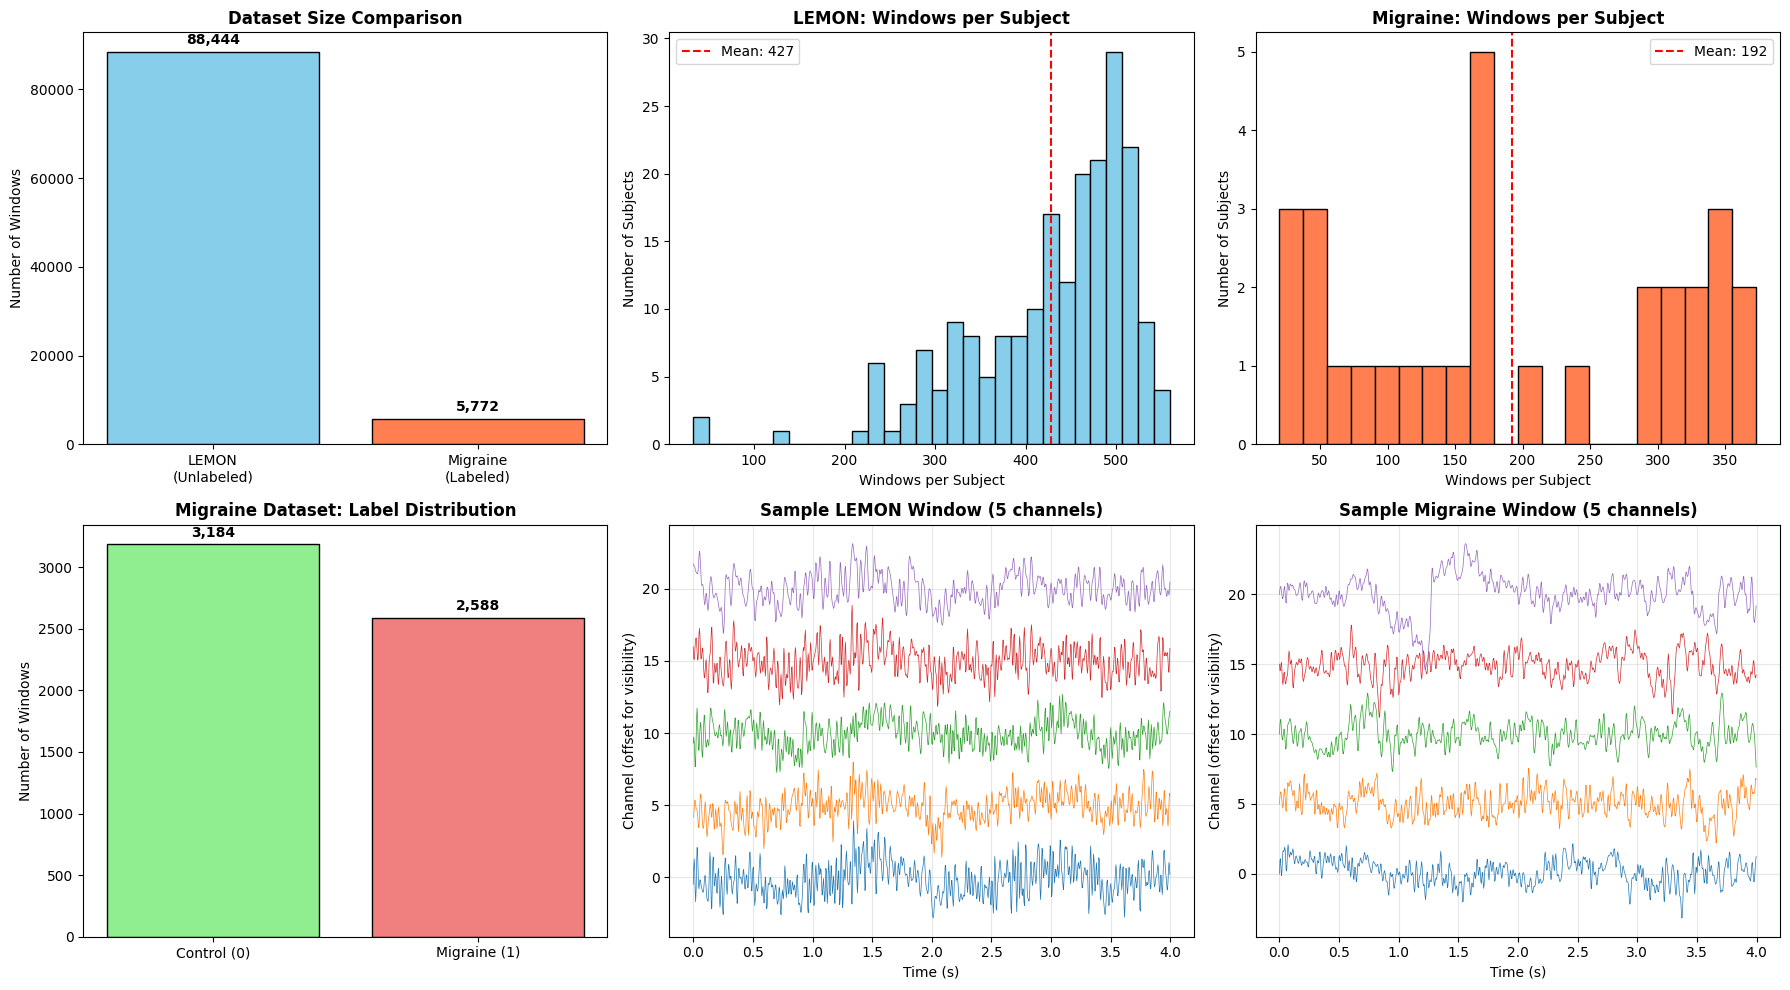

✓ Dataset statistics visualization saved


In [12]:
# Load saved datasets for visualization
lemon_X = None
migraine_X = None

if (output_dir / 'lemon_windows.npy').exists():
    lemon_X = np.load(output_dir / 'lemon_windows.npy', mmap_mode='r')
    
if (output_dir / 'migraine_windows.npy').exists():
    migraine_X = np.load(output_dir / 'migraine_windows.npy', mmap_mode='r')

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Dataset size comparison
datasets = []
sizes = []
if lemon_X is not None:
    datasets.append('LEMON\n(Unlabeled)')
    sizes.append(len(lemon_X))
if migraine_X is not None:
    datasets.append('Migraine\n(Labeled)')
    sizes.append(len(migraine_X))

if len(datasets) > 0:
    axes[0, 0].bar(datasets, sizes, color=['skyblue', 'coral'], edgecolor='black')
    axes[0, 0].set_ylabel('Number of Windows')
    axes[0, 0].set_title('Dataset Size Comparison', fontweight='bold')
    for i, v in enumerate(sizes):
        axes[0, 0].text(i, v + max(sizes)*0.02, f"{v:,}", ha='center', fontweight='bold')

# 2. Windows per subject (LEMON)
if lemon_meta is not None:
    windows_per_subject = lemon_meta.groupby('subject_id').size()
    axes[0, 1].hist(windows_per_subject, bins=30, color='skyblue', edgecolor='black')
    axes[0, 1].axvline(windows_per_subject.mean(), color='red', linestyle='--', 
                       label=f'Mean: {windows_per_subject.mean():.0f}')
    axes[0, 1].set_xlabel('Windows per Subject')
    axes[0, 1].set_ylabel('Number of Subjects')
    axes[0, 1].set_title('LEMON: Windows per Subject', fontweight='bold')
    axes[0, 1].legend()

# 3. Windows per subject (Migraine)
if migraine_meta is not None:
    windows_per_subject_migraine = migraine_meta.groupby('subject_id').size()
    axes[0, 2].hist(windows_per_subject_migraine, bins=20, color='coral', edgecolor='black')
    axes[0, 2].axvline(windows_per_subject_migraine.mean(), color='red', linestyle='--',
                       label=f'Mean: {windows_per_subject_migraine.mean():.0f}')
    axes[0, 2].set_xlabel('Windows per Subject')
    axes[0, 2].set_ylabel('Number of Subjects')
    axes[0, 2].set_title('Migraine: Windows per Subject', fontweight='bold')
    axes[0, 2].legend()

# 4. Label distribution (Migraine)
if migraine_y is not None:
    label_counts = pd.Series(migraine_y).value_counts().sort_index()
    axes[1, 0].bar(['Control (0)', 'Migraine (1)'], label_counts.values, 
                   color=['lightgreen', 'lightcoral'], edgecolor='black')
    axes[1, 0].set_ylabel('Number of Windows')
    axes[1, 0].set_title('Migraine Dataset: Label Distribution', fontweight='bold')
    for i, v in enumerate(label_counts.values):
        axes[1, 0].text(i, v + max(label_counts)*0.02, f"{v:,}", ha='center', fontweight='bold')

# 5. Sample EEG window visualization (LEMON)
if lemon_X is not None:
    sample_window = lemon_X[0, :5, :]  # First 5 channels
    time_axis = np.arange(sample_window.shape[1]) / 250.0  # Convert to seconds
    for ch_idx in range(sample_window.shape[0]):
        axes[1, 1].plot(time_axis, sample_window[ch_idx, :] + ch_idx * 5, linewidth=0.5)
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Channel (offset for visibility)')
    axes[1, 1].set_title('Sample LEMON Window (5 channels)', fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

# 6. Sample EEG window visualization (Migraine)
if migraine_X is not None:
    sample_window_m = migraine_X[0, :5, :]  # First 5 channels
    time_axis_m = np.arange(sample_window_m.shape[1]) / 250.0
    for ch_idx in range(sample_window_m.shape[0]):
        axes[1, 2].plot(time_axis_m, sample_window_m[ch_idx, :] + ch_idx * 5, linewidth=0.5)
    axes[1, 2].set_xlabel('Time (s)')
    axes[1, 2].set_ylabel('Channel (offset for visibility)')
    axes[1, 2].set_title('Sample Migraine Window (5 channels)', fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'windowed_dataset_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Dataset statistics visualization saved")

## 8. Summary Report

Comprehensive summary of windowing outcomes.

In [13]:
print("\n" + "="*70)
print("WINDOWED DATASET CREATION SUMMARY")
print("="*70)

print("\nConfiguration:")
print("-" * 70)
print(f"  Window duration: {builder.window_duration}s ({int(builder.window_duration * 250)} samples)")
print(f"  Overlap: {builder.overlap * 100}% ({builder.window_duration * builder.overlap}s)")
print(f"  Stride: {builder.window_duration * (1 - builder.overlap)}s")
print(f"  Artifact threshold: {builder.artifact_threshold * 1e6} µV")
print(f"  Normalization: Per-subject z-score")
print(f"  Data type: float32 (memory optimized)")

if lemon_meta is not None:
    total_lemon_windows = len(lemon_meta)
    print("\nLEMON Dataset (Unsupervised Pretraining):")
    print("-" * 70)
    print(f"  Subjects processed: {lemon_meta['subject_id'].nunique()}")
    print(f"  Total windows: {total_lemon_windows:,}")
    if lemon_X is not None:
        print(f"  Tensor shape: {lemon_X.shape}")
        print(f"  Memory size: {lemon_X.nbytes / 1024**2:.1f} MB")
    print(f"  Avg windows/subject: {total_lemon_windows / lemon_meta['subject_id'].nunique():.0f}")

if migraine_meta is not None:
    total_migraine_windows = len(migraine_meta)
    print("\nMigraine Dataset (Supervised Learning):")
    print("-" * 70)
    print(f"  Subjects processed: {migraine_meta['subject_id'].nunique()}")
    print(f"  Total windows: {total_migraine_windows:,}")
    if migraine_X is not None:
        print(f"  Tensor shape: {migraine_X.shape}")
        print(f"  Memory size: {migraine_X.nbytes / 1024**2:.1f} MB")
    print(f"  Avg windows/subject: {total_migraine_windows / migraine_meta['subject_id'].nunique():.0f}")
    print(f"\n  Label Distribution:")
    print(f"    Control (0): {(migraine_y == 0).sum():,} windows ({(migraine_y == 0).sum() / len(migraine_y) * 100:.1f}%)")
    print(f"    Migraine (1): {(migraine_y == 1).sum():,} windows ({(migraine_y == 1).sum() / len(migraine_y) * 100:.1f}%)")

if lemon_meta is not None and migraine_meta is not None:
    total_windows = len(lemon_meta) + len(migraine_meta)
    total_subjects = lemon_meta['subject_id'].nunique() + migraine_meta['subject_id'].nunique()
    total_memory = 0
    if lemon_X is not None:
        total_memory += lemon_X.nbytes
    if migraine_X is not None:
        total_memory += migraine_X.nbytes
    
    print("\nCombined Dataset:")
    print("-" * 70)
    print(f"  Total subjects: {total_subjects}")
    print(f"  Total windows: {total_windows:,}")
    if total_memory > 0:
        print(f"  Total size: {total_memory / 1024**2:.1f} MB")

print("\n" + "="*70)
print("✓ Windowed datasets created successfully!")
print(f"✓ Datasets saved to: {output_dir}")
print("="*70)


WINDOWED DATASET CREATION SUMMARY

Configuration:
----------------------------------------------------------------------
  Window duration: 4.0s (1000 samples)
  Overlap: 50.0% (2.0s)
  Stride: 2.0s
  Artifact threshold: 250.0 µV
  Normalization: Per-subject z-score
  Data type: float32 (memory optimized)

LEMON Dataset (Unsupervised Pretraining):
----------------------------------------------------------------------
  Subjects processed: 207
  Total windows: 88,444
  Tensor shape: (88444, 62, 1000)
  Memory size: 20918.0 MB
  Avg windows/subject: 427

Migraine Dataset (Supervised Learning):
----------------------------------------------------------------------
  Subjects processed: 30
  Total windows: 5,772
  Tensor shape: (5772, 135, 1000)
  Memory size: 2972.5 MB
  Avg windows/subject: 192

  Label Distribution:
    Control (0): 3,184 windows (55.2%)
    Migraine (1): 2,588 windows (44.8%)

Combined Dataset:
----------------------------------------------------------------------
  T

## 9. Verify Data Integrity

Sanity checks to ensure data quality before training.

In [14]:
# Reload datasets if they were cleared from memory
if lemon_X is None and (output_dir / 'lemon_windows.npy').exists():
    lemon_X = np.load(output_dir / 'lemon_windows.npy', mmap_mode='r')
    
if migraine_X is None and (output_dir / 'migraine_windows.npy').exists():
    migraine_X = np.load(output_dir / 'migraine_windows.npy', mmap_mode='r')

print("\nData Integrity Checks:")
print("="*70)

# Check for NaN or Inf values
if lemon_X is not None:
    # Sample check (don't load entire array into memory)
    sample_lemon = lemon_X[:1000]  # Check first 1000 windows
    has_nan = np.isnan(sample_lemon).any()
    has_inf = np.isinf(sample_lemon).any()
    print(f"LEMON - NaN values: {'❌ FOUND' if has_nan else '✓ None'}")
    print(f"LEMON - Inf values: {'❌ FOUND' if has_inf else '✓ None'}")
    print(f"LEMON - Value range (sample): [{sample_lemon.min():.2f}, {sample_lemon.max():.2f}]")
    print(f"LEMON - Data type: {lemon_X.dtype}")
    del sample_lemon

if migraine_X is not None:
    sample_migraine = migraine_X[:1000]  # Check first 1000 windows
    has_nan_m = np.isnan(sample_migraine).any()
    has_inf_m = np.isinf(sample_migraine).any()
    print(f"\nMigraine - NaN values: {'❌ FOUND' if has_nan_m else '✓ None'}")
    print(f"Migraine - Inf values: {'❌ FOUND' if has_inf_m else '✓ None'}")
    print(f"Migraine - Value range (sample): [{sample_migraine.min():.2f}, {sample_migraine.max():.2f}]")
    print(f"Migraine - Data type: {migraine_X.dtype}")
    del sample_migraine

# Verify normalization (should be approximately N(0,1))
# Sample-based check to avoid loading entire array
if lemon_X is not None:
    sample_lemon = lemon_X[:1000]
    lemon_mean = np.mean(sample_lemon)
    lemon_std = np.std(sample_lemon)
    print(f"\nLEMON - Sample mean: {lemon_mean:.4f} (should be ~0)")
    print(f"LEMON - Sample std: {lemon_std:.4f} (should be ~1)")
    del sample_lemon

if migraine_X is not None:
    sample_migraine = migraine_X[:1000]
    migraine_mean = np.mean(sample_migraine)
    migraine_std = np.std(sample_migraine)
    print(f"\nMigraine - Sample mean: {migraine_mean:.4f} (should be ~0)")
    print(f"Migraine - Sample std: {migraine_std:.4f} (should be ~1)")
    del sample_migraine

print("\n" + "="*70)
print("✓ Data integrity verified!")
print("="*70)


Data Integrity Checks:
LEMON - NaN values: ✓ None
LEMON - Inf values: ✓ None
LEMON - Value range (sample): [-17.77, 23.62]
LEMON - Data type: float32

Migraine - NaN values: ✓ None
Migraine - Inf values: ✓ None
Migraine - Value range (sample): [-25.67, 27.75]
Migraine - Data type: float32

LEMON - Sample mean: -0.0001 (should be ~0)
LEMON - Sample std: 0.9962 (should be ~1)

Migraine - Sample mean: -0.0001 (should be ~0)
Migraine - Sample std: 0.9983 (should be ~1)

✓ Data integrity verified!


## 10. Next Steps

1. ✅ LEMON preprocessing complete
2. ✅ Migraine preprocessing complete
3. ✅ **Windowed datasets created** (this notebook)
4. ⏭️ Run `04_Transfer_Learning_Training.ipynb` to train the model

---

## References

1. Chen, T., et al. (2020). "A simple framework for contrastive learning of visual representations." *International Conference on Machine Learning*, 1597-1607.

2. Craik, A., et al. (2019). "Deep learning for electroencephalogram (EEG) classification tasks: a review." *Journal of Neural Engineering* 16(3), 031001.

3. Delorme, A., et al. (2007). "Enhanced detection of artifacts in EEG data using higher-order statistics and independent component analysis." *NeuroImage* 34(4), 1443-1449.

4. Kostas, D., et al. (2021). "BENDR: Using transformers and a contrastive self-supervised learning task to learn from massive amounts of EEG data." *Frontiers in Human Neuroscience* 15, 653659.

5. Krizhevsky, A., et al. (2012). "ImageNet classification with deep convolutional neural networks." *Advances in Neural Information Processing Systems* 25, 1097-1105.

6. Lawhern, V. J., et al. (2018). "EEGNet: a compact convolutional neural network for EEG-based brain–computer interfaces." *Journal of Neural Engineering* 15(5), 056013.

7. LeCun, Y., et al. (2012). "Efficient BackProp." *Neural Networks: Tricks of the Trade*, Springer, 9-48.

8. Roy, Y., et al. (2019). "Deep learning-based electroencephalography analysis: a systematic review." *Journal of Neural Engineering* 16(5), 051001.

9. Schirrmeister, R. T., et al. (2017). "Deep learning with convolutional neural networks for EEG decoding and visualization." *Human Brain Mapping* 38(11), 5391-5420.

10. Schulz, E., et al. (2016). "Decoding an individual's sensitivity to pain from the multivariate analysis of EEG data." *Cerebral Cortex* 26(4), 1722-1734.

11. Varoquaux, G., & Cheplygina, V. (2022). "Machine learning for medical imaging: methodological failures and recommendations for the future." *NPJ Digital Medicine* 5(1), 48.